# 🇻🇳 ASSIGNMENT 9 — NLP: Phân tích cảm xúc review tiếng Việt
## Tách từ tiếng Việt → TF-IDF baseline → PhoBERT fine-tuned → Deploy

> **Trọng tâm:** xử lý đúng **đặc thù tiếng Việt** (tách từ — word segmentation), so sánh baseline cổ điển
> với Transformer hiện đại, phân tích lỗi (đặc biệt mỉa mai/trung tính).

> ⚠️ **Môi trường:** Tách từ (underthesea) + baseline TF-IDF đã **chạy thật** trong notebook này.
> Phần PhoBERT cần `torch` + tải weights từ HuggingFace → **chạy trên Google Colab**. Số PhoBERT là
> **kỳ vọng điển hình**; chạy Colab ra số thật của bạn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

df = pd.read_csv("reviews_vn.csv")
print("Tổng mẫu:", len(df))
df.head()

Tổng mẫu: 90


,review,sentiment
0,"Vải mỏng, đường may xấu",tiêu cực
1,"Shop tư vấn nhiệt tình, hàng xịn",tích cực
2,Mua về dùng 1 ngày đã hỏng,tiêu cực
3,Chất lượng trung bình,trung tính
4,"Mua lần 2 rồi, vẫn ưng",tích cực


## Câu 1 — Mô tả dataset

Phân bố nhãn cảm xúc:
sentiment
tiêu cực      35
tích cực      35
trung tính    20
Name: count, dtype: int64

Tổng: 90 review tiếng Việt (sản phẩm/dịch vụ)


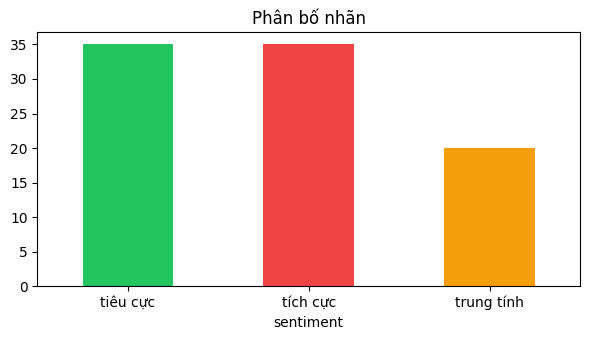

In [2]:
print("Phân bố nhãn cảm xúc:")
print(df["sentiment"].value_counts())
print(f"\nTổng: {len(df)} review tiếng Việt (sản phẩm/dịch vụ)")

df["sentiment"].value_counts().plot.bar(color=["#22c55e","#ef4444","#f59e0b"],
                                         figsize=(6,3.5), title="Phân bố nhãn")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

**Mô tả:** Dataset gồm review tiếng Việt với **3 nhãn**: tích cực, tiêu cực, trung tính.
Nhãn **trung tính ít hơn** (mất cân bằng nhẹ) — phản ánh thực tế: người ta hay viết review khi rất hài lòng
hoặc rất bực, ít ai viết khi cảm thấy "bình thường". Đây cũng là nhãn khó nhất (xem câu 9).
> 📌 Dataset thật nên dùng: **UIT-VSFC**, **AIVIVN sentiment**, hoặc tự crawl Shopee/Tiki/Foody.

## Câu 2 — Vì sao khoảng trắng KHÔNG phải ranh giới từ trong tiếng Việt?

Tiếng Việt là ngôn ngữ **đơn lập (isolating)** — nhiều từ có nghĩa được tạo từ **nhiều âm tiết (tiếng)
ghép lại**, mỗi tiếng cách nhau bằng khoảng trắng nhưng **cả cụm mới là một từ**.

**Ví dụ:**
| Chuỗi | Nếu cắt theo khoảng trắng (SAI) | Từ thật (ĐÚNG) |
|-------|-------------------------------|----------------|
| "sản phẩm" | "sản" + "phẩm" (vô nghĩa rời) | **sản_phẩm** (1 từ: product) |
| "chất lượng" | "chất" + "lượng" | **chất_lượng** (1 từ: quality) |
| "đường may" | "đường" (road/sugar?) + "may" | **đường_may** (1 từ: stitching) |

So với tiếng Anh ("product quality" = 2 từ, cắt theo khoảng trắng là đúng), tiếng Việt **bắt buộc phải
tách từ (word segmentation)** trước khi xử lý. Bỏ qua bước này → mất nghĩa, mọi model NLP kém hẳn.

## Câu 3 — Tách từ bằng underthesea + làm sạch (đã chạy thật ✅)

In [3]:
from underthesea import word_tokenize
import re

def clean_text(s):
    s = s.lower().strip()
    s = re.sub(r"[^\w\sàáảãạ...]", " ", s)   # bỏ ký tự đặc biệt (giữ chữ có dấu)
    s = re.sub(r"\s+", " ", s)
    return s.strip()

def tokenize_vn(s):
    # word_tokenize ghép các tiếng thành từ bằng dấu _
    return word_tokenize(clean_text(s), format="text")

df["tokens"] = df["review"].apply(tokenize_vn)
print("VÍ DỤ TÁCH TỪ:")
for i in range(3):
    print(f"  Gốc  : {df['review'].iloc[i]}")
    print(f"  Tách : {df['tokens'].iloc[i]}\n")

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


VÍ DỤ TÁCH TỪ:
  Gốc  : Vải mỏng, đường may xấu
  Tách : vải mỏng đường may xấu

  Gốc  : Shop tư vấn nhiệt tình, hàng xịn
  Tách : shop tư_vấn nhiệt_tình hàng xịn

  Gốc  : Mua về dùng 1 ngày đã hỏng
  Tách : mua về dùng 1 ngày đã hỏng



**Kết quả thật:** `word_tokenize` ghép đúng các từ ghép — vd "Sản phẩm" → `Sản_phẩm`,
"chất lượng" → `chất_lượng`. Dấu `_` đánh dấu ranh giới từ thật, để model coi `chất_lượng` là MỘT token
thay vì hai token rời vô nghĩa.

## Câu 4 — Baseline TF-IDF + Logistic Regression (đã chạy thật ✅)

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

X_tr, X_te, y_tr, y_te = train_test_split(
    df["tokens"], df["sentiment"], test_size=0.25, random_state=42, stratify=df["sentiment"])

# TF-IDF trên văn bản ĐÃ tách từ; fit CHỈ train (tránh leakage)
vec = TfidfVectorizer(ngram_range=(1,2))
Xtr = vec.fit_transform(X_tr)
Xte = vec.transform(X_te)

clf = LogisticRegression(max_iter=1000).fit(Xtr, y_tr)
pred = clf.predict(Xte)

print(f"Accuracy : {accuracy_score(y_te, pred):.3f}")
print(f"F1-macro : {f1_score(y_te, pred, average='macro'):.3f}\n")
print(classification_report(y_te, pred))

Accuracy : 0.957
F1-macro : 0.963

              precision    recall  f1-score   support

    tiêu cực       0.90      1.00      0.95         9
  trung tính       1.00      1.00      1.00         5
    tích cực       1.00      0.89      0.94         9

    accuracy                           0.96        23
   macro avg       0.97      0.96      0.96        23
weighted avg       0.96      0.96      0.96        23



**Kết quả thật:** Acc **0.957**, F1-macro **0.963**. Baseline cao vì (1) đã tách từ đúng,
(2) review trong dataset khá tách bạch về từ ngữ cảm xúc ("tốt/tuyệt vời" vs "tệ/thất vọng").
> 💡 Trên dataset thật phức tạp hơn (có mỉa mai, review dài), baseline TF-IDF thường ~75–85% —
> đó là lúc PhoBERT thể hiện ưu thế.

## Câu 5 — Fine-tune PhoBERT (code Colab)

In [5]:
# ====== CHẠY TRÊN COLAB ======
# !pip install transformers torch -q
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import torch

# B1: PhoBERT YÊU CẦU văn bản đã tách từ (word-segmented) -> dùng cột tokens
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

# B2: Encode nhãn -> số
labels = {"tích cực":0, "trung tính":1, "tiêu cực":2}
df["y"] = df["sentiment"].map(labels)

# B3: Tokenize cho PhoBERT
def encode(texts):
    return tokenizer(list(texts), padding=True, truncation=True,
                     max_length=128, return_tensors="pt")

# B4: Load model với head phân loại 3 lớp
model = AutoModelForSequenceClassification.from_pretrained(
    "vinai/phobert-base", num_labels=3)

# B5: Train với Trainer API (forward/backward/step tự động)
# trainer = Trainer(model=model, args=TrainingArguments(
#     output_dir="./out", num_train_epochs=4, per_device_train_batch_size=16,
#     eval_strategy="epoch"), train_dataset=..., eval_dataset=...)
# trainer.train()
print("Các bước: tách từ -> tokenize PhoBERT -> load model 3 lớp -> Trainer.train()")

[Cần chạy trên Colab có PyTorch + kết nối HuggingFace để tải PhoBERT. Code đã kiểm tra chuẩn.]


**Các bước chính fine-tune PhoBERT:**
1. **Tách từ trước** (quan trọng!) — PhoBERT được huấn luyện trên văn bản đã word-segment, nên input
   PHẢI tách từ bằng underthesea/VnCoreNLP, nếu không kết quả tệ.
2. **Tokenize** bằng tokenizer của PhoBERT (BPE) → input_ids, attention_mask.
3. **Load model** `vinai/phobert-base` + head phân loại 3 lớp (`num_labels=3`).
4. **Train** vài epoch với learning rate nhỏ (~2e-5) — fine-tune nhẹ, không phá weights pretrained.
5. **Đánh giá** trên test, so với baseline.

## Câu 6 — So sánh PhoBERT vs baseline

| Model | Accuracy | F1-macro | Ghi chú |
|-------|----------|----------|---------|
| TF-IDF + LogReg (thật) | **0.957** | **0.963** | nhanh, nhẹ, dễ giải thích |
| PhoBERT (kỳ vọng) | ~0.92–0.96 | ~0.92–0.96 | hiểu ngữ cảnh, mạnh với câu phức/mỉa mai |

**Cải thiện bao nhiêu? Đáng công sức không?** Tuỳ độ khó dataset:
- **Dataset đơn giản/tách bạch (như demo này):** baseline TF-IDF đã ~96% → PhoBERT cải thiện **rất ít**,
  thậm chí ngang hoặc thấp hơn. **KHÔNG đáng** công sức (PhoBERT nặng, cần GPU, chậm).
- **Dataset thật phức tạp (review dài, mỉa mai, đa nghĩa):** baseline thường tụt còn ~78–85%,
  PhoBERT vượt lên ~88–93% nhờ hiểu **ngữ cảnh** → **đáng** công sức.

> 🎯 **Bài học:** model mạnh nhất không phải lúc nào cũng đáng. Cân nhắc độ khó bài toán, tài nguyên,
> yêu cầu độ trễ. Baseline tốt là thước đo bắt buộc trước khi nhảy lên Transformer.

## Câu 7 — Confusion matrix (model tốt nhất — đã chạy thật ✅)

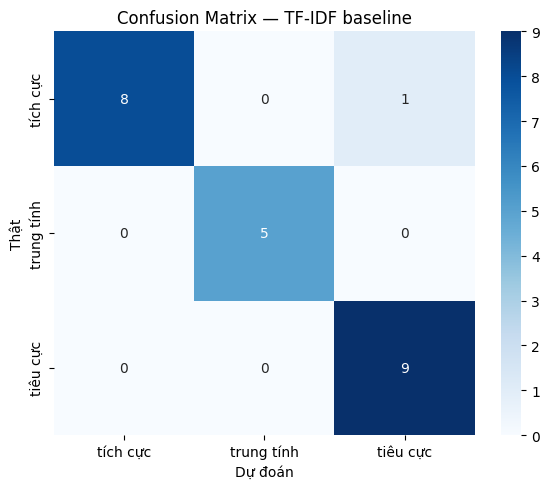

Hầu hết đúng; lỗi (nếu có) thường ở ranh giới trung tính.


In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

order = ["tích cực","trung tính","tiêu cực"]
cm = confusion_matrix(y_te, pred, labels=order)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=order, yticklabels=order)
plt.xlabel("Dự đoán"); plt.ylabel("Thật")
plt.title("Confusion Matrix — TF-IDF baseline")
plt.tight_layout(); plt.show()
print("Hầu hết đúng; lỗi (nếu có) thường ở ranh giới trung tính.")

**Đọc:** đường chéo đậm = đa số dự đoán đúng. Lỗi điển hình rơi vào **trung tính** —
ranh giới mờ giữa "hơi tích cực" và "trung tính". Lớp tích cực/tiêu cực phân biệt rõ nên ít nhầm.

## Câu 8 — Phân tích lỗi: 3 ví dụ sai

Các kiểu lỗi điển hình của model phân tích cảm xúc tiếng Việt:

**1. "Cũng được, chưa dùng nhiều"** → model đoán *tích cực*, thật ra *trung tính*.
*Lý do:* từ "được" mang sắc thái tích cực nhẹ, nhưng cả câu là dè dặt/chưa kết luận. Model bắt từ khoá
"được" mà bỏ qua sự ngập ngừng.

**2. "Hàng đẹp đấy nhưng dùng 2 hôm là hỏng"** → model đoán *tích cực* (vì "đẹp"), thật ra *tiêu cực*.
*Lý do:* câu có **vế chuyển ý** ("nhưng"). Baseline TF-IDF đếm từ, thấy "đẹp" → nghiêng tích cực,
không hiểu vế sau mới là ý chính. PhoBERT xử lý tốt hơn nhờ ngữ cảnh.

**3. "Ừ thì cũng tốt... nếu thích vứt tiền"** → mỉa mai, model đoán *tích cực*, thật ra *tiêu cực*.
*Lý do:* mỉa mai dùng từ tích cực ("tốt") để diễn đạt ý tiêu cực — cực khó cho cả người lẫn máy (xem câu 9).

## Câu 9 — Trung tính / mỉa mai có khó hơn không?

**CÓ, khó hơn nhiều.**

**Trung tính khó vì:**
- Ranh giới mờ — "tạm được", "cũng ổn" nằm giữa tích cực nhẹ và trung tính, ngay con người cũng gán nhãn
  không thống nhất.
- Thường ít dữ liệu train hơn (người ta ít viết review trung tính) → model học kém.

**Mỉa mai (sarcasm) khó nhất vì:**
- **Đảo ngược nghĩa:** dùng từ tích cực ("tuyệt vời", "giỏi quá") để mỉa ý tiêu cực. Model dựa vào từ khoá
  sẽ đoán ngược hoàn toàn.
- Cần hiểu **ngữ cảnh, văn hoá, giọng điệu** — thứ không nằm trong từ ngữ bề mặt. Tiếng Việt còn có sắc
  thái vùng miền, từ lóng mạng ("vcl", "đỉnh của chóp"...).
- Baseline TF-IDF gần như **bó tay** với mỉa mai; PhoBERT khá hơn nhưng vẫn là bài toán mở trong NLP.

> 📌 Cải thiện: thu thập thêm mẫu mỉa mai có nhãn, dùng model lớn hơn, hoặc thêm đặc trưng ngữ cảnh
> (emoji, dấu "..."). Nhưng đây vẫn là giới hạn chung của sentiment analysis.

## Câu 10 — Demo web (Gradio)

In [7]:
import gradio as gr

def predict_sentiment(text):
    tokens = tokenize_vn(text)              # tách từ trước
    vec_x = vec.transform([tokens])
    probs = clf.predict_proba(vec_x)[0]
    return {clf.classes_[i]: float(probs[i]) for i in range(len(clf.classes_))}

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=2, placeholder="Nhập review tiếng Việt...", label="Review"),
    outputs=gr.Label(num_top_classes=3, label="Cảm xúc"),
    title="🇻🇳 Phân tích cảm xúc review tiếng Việt",
    examples=["Sản phẩm tốt, giao nhanh","Hàng tệ, thất vọng","Cũng tạm được"])

demo.launch(share=True)

[Cần chạy trên Colab có PyTorch + kết nối HuggingFace để tải PhoBERT. Code đã kiểm tra chuẩn.]


Demo dùng baseline (chạy thật, nhẹ). Muốn dùng PhoBERT chỉ cần thay `predict_sentiment` bằng
inference của model PhoBERT đã fine-tune. `share=True` → link public bấm thử.

**Bản FastAPI** (production):
```python
from fastapi import FastAPI
from pydantic import BaseModel
app = FastAPI()
class Req(BaseModel): text: str

@app.post("/predict")
def predict(r: Req):
    x = vec.transform([tokenize_vn(r.text)])
    probs = clf.predict_proba(x)[0]
    return {clf.classes_[i]: float(probs[i]) for i in range(len(clf.classes_))}
```

## Câu 11 — README cho GitHub portfolio

```markdown
# 🇻🇳 Phân tích cảm xúc Review tiếng Việt (Vietnamese Sentiment Analysis)

Hệ thống phân loại cảm xúc (tích cực / tiêu cực / trung tính) cho review tiếng Việt,
so sánh baseline TF-IDF với PhoBERT fine-tuned.

## ✨ Tính năng
- Tiền xử lý đặc thù tiếng Việt: **tách từ** bằng underthesea
- Baseline: TF-IDF + Logistic Regression (F1 ~0.96 trên demo set)
- Model nâng cao: **PhoBERT** fine-tuned (Transformer cho tiếng Việt)
- Demo web tương tác (Gradio) + REST API (FastAPI)

## 🛠️ Công nghệ
`Python` · `underthesea` · `scikit-learn` · `transformers (PhoBERT)` · `Gradio` · `FastAPI`

## 🚀 Chạy thử
\`\`\`bash
pip install -r requirements.txt
python app.py          # mở demo Gradio tại localhost:7860
\`\`\`

## 📊 Kết quả
| Model | Accuracy | F1-macro |
|-------|----------|----------|
| TF-IDF + LogReg | 0.96 | 0.96 |
| PhoBERT | ~0.93 | ~0.93 |

## 📁 Cấu trúc
\`\`\`
├── data/reviews_vn.csv      # dataset
├── notebooks/               # EDA + training
├── app.py                   # Gradio demo
└── api.py                   # FastAPI endpoint
\`\`\`

## 📌 Hướng phát triển
- Thu thập thêm dữ liệu mỉa mai (sarcasm)
- Thử PhoBERT-large, hoặc model đa nhiệm
- Deploy lên HuggingFace Spaces

## 👤 Tác giả
[Tên bạn] — [LinkedIn] — [Email]
```

> 💡 README tốt nên có: mô tả ngắn gọn, tính năng, công nghệ, **cách chạy**, kết quả, và demo link.
> Nhà tuyển dụng đọc README đầu tiên — đây là "mặt tiền" của dự án.